# Benchmarks

This notebook benchmarks left-vs-right hand motor imagery on the PhysioNet EEG Motor Movement/Imagery dataset using runs `4`, `8`, and `12`.

It is organized in stages so the figures appear near the relevant analysis:

- inspect the loaded dataset and sensorimotor channels first
- benchmark `CSP + LDA` plus Braindecode motor-imagery models with all channels
- compare accuracy and training cost immediately after the benchmark cell
- sweep smaller sensorimotor channel sets and plot how much performance is retained


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import (
    ATCNet,
    CTNet,
    Deep4Net,
    EEGNet,
    FBCNet,
    FBLightConvNet,
    AttentionBaseNet,
    ShallowFBCSPNet,
)
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.io import concatenate_raws, read_raw_edf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 4.0)
FILTER_BAND = (7.0, 30.0)
RESAMPLE_SFREQ = 160.0
TEST_SIZE = 0.2
VAL_SIZE = 0.2
MAX_SUBJECTS = None  # Set to a small number like 10 for a quick smoke test.
FETCH_MISSING = False  # Flip to True only if you want MNE to download missing runs.
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MIN_CHANNEL_TOLERANCE = 0.02  # smallest subset within this absolute accuracy gap is considered "good enough"
SENSORIMOTOR_CHANNEL_SETS = {
    "motor_strip_3": ["C3", "Cz", "C4"],
    "motor_strip_5": ["FC3", "C3", "Cz", "C4", "FC4"],
    "sensorimotor_9": ["FC3", "FCz", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"],
    "sensorimotor_17": [
        "FC5",
        "FC3",
        "FC1",
        "FCz",
        "FC2",
        "FC4",
        "FC6",
        "C5",
        "C3",
        "C1",
        "Cz",
        "C2",
        "C4",
        "C6",
        "CP3",
        "CPz",
        "CP4",
    ],
}
MODEL_NAMES = [
    "CSP + LDA",
    "EEGNet",
    "ShallowConvNet",
    "DeepConvNet",
    "AttentionBaseNet",
    "CTNet",
    "FBLightConvNet",
    "FBCNet",
    "ATCNet",
]
CHANNEL_STUDY_MODELS = (
    None  # Use a list of model names here to restrict the channel sweep.
)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def subject_root_candidates(data_root: Path = DATA_ROOT) -> list[Path]:
    return [
        data_root,
        data_root / "MNE-eegbci-data" / "files" / "eegmmidb" / "1.0.0",
    ]


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    subjects = set()
    for root in subject_root_candidates(data_root):
        if not root.exists():
            continue
        for path in root.glob("S[0-9][0-9][0-9]"):
            if path.is_dir():
                subjects.add(int(path.name[1:]))
    return sorted(subjects)


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    file_names = [f"{subject_name}R{run:02d}.edf" for run in runs]
    for root in subject_root_candidates(data_root):
        subject_dir = root / subject_name
        candidate_paths = [subject_dir / file_name for file_name in file_names]
        if all(path.exists() for path in candidate_paths):
            return candidate_paths
    return [(data_root / subject_name / file_name) for file_name in file_names]


def get_subject_run_paths(
    subject: int, runs: list[int], fetch_missing: bool = FETCH_MISSING
) -> list[Path]:
    paths = local_run_paths(subject, runs)
    if all(path.exists() for path in paths):
        return paths
    if fetch_missing:
        return [
            Path(path)
            for path in eegbci.load_data(
                subject, runs, path=str(DATA_ROOT), update_path=True
            )
        ]
    missing = [path.name for path in paths if not path.exists()]
    raise FileNotFoundError(
        f"Missing EDF files for subject {subject:03d}: {missing}. "
        "Set FETCH_MISSING=True after you are ready to let MNE download them."
    )


def load_subject_epochs(subject: int, runs: list[int] = RUNS) -> dict:
    raw_paths = get_subject_run_paths(subject, runs)
    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in raw_paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )

    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)
    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)

    return {
        "subject": subject,
        "X": X,
        "y": y,
        "epochs": epochs,
    }


def build_dataset(subjects: list[int] | None = None) -> dict:
    available_subjects = infer_available_subjects()
    if subjects is None:
        subjects = available_subjects
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]
    if not subjects:
        raise RuntimeError(
            "No locally available EEGBCI subjects were found under /NAS/aniruddham/mne/data. "
            "Fetch the dataset first, or set FETCH_MISSING=True."
        )

    X_parts = []
    y_parts = []
    groups = []
    kept_subjects = []
    example_epochs = None
    channel_names = None
    chs_info = None
    skipped = []

    for subject in subjects:
        try:
            loaded = load_subject_epochs(subject)
        except FileNotFoundError as exc:
            skipped.append(str(exc))
            continue

        if channel_names is None:
            channel_names = loaded["epochs"].ch_names
            chs_info = deepcopy(loaded["epochs"].info["chs"])
            example_epochs = loaded["epochs"].copy()
        else:
            if loaded["epochs"].ch_names != channel_names:
                raise RuntimeError(f"Channel mismatch for subject {subject:03d}")

        X_parts.append(loaded["X"])
        y_parts.append(loaded["y"])
        groups.append(np.full(len(loaded["y"]), subject))
        kept_subjects.append(subject)

    if not X_parts:
        raise RuntimeError(
            "No subjects could be loaded from the currently available files."
        )

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "subjects": kept_subjects,
        "channel_names": list(channel_names),
        "chs_info": chs_info,
        "sfreq": float(example_epochs.info["sfreq"]),
        "example_epochs": example_epochs,
        "skipped": skipped,
    }


set_seed()
dataset = build_dataset()

dataset_summary = pd.DataFrame(
    {
        "metric": [
            "subjects_used",
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels",
            "sampling_rate_hz",
            "samples_per_epoch",
        ],
        "value": [
            len(dataset["subjects"]),
            len(dataset["y"]),
            int((dataset["y"] == 0).sum()),
            int((dataset["y"] == 1).sum()),
            len(dataset["channel_names"]),
            dataset["sfreq"],
            dataset["X"].shape[-1],
        ],
    }
)

display(dataset_summary)
if dataset["skipped"]:
    print("Skipped subjects with missing runs:")
    for item in dataset["skipped"][:10]:
        print(f"  - {item}")
    if len(dataset["skipped"]) > 10:
        print(f"  ... and {len(dataset['skipped']) - 10} more")


,metric,value
0,subjects_used,109.0
1,epochs_total,4898.0
2,left_trials,2470.0
3,right_trials,2428.0
4,channels,64.0
5,sampling_rate_hz,160.0
6,samples_per_epoch,560.0


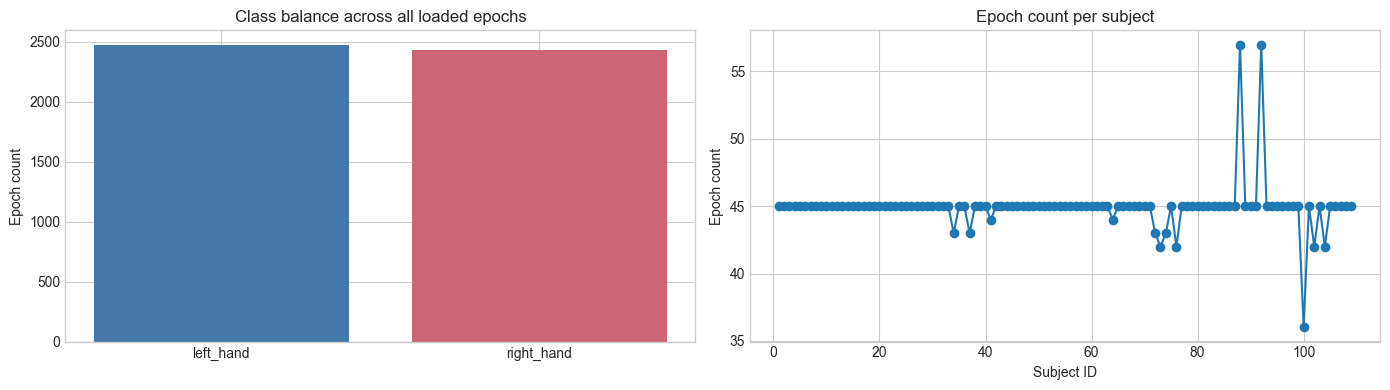

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

labels, counts = np.unique(dataset["y"], return_counts=True)
axes[0].bar(["left_hand", "right_hand"], counts, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance across all loaded epochs")
axes[0].set_ylabel("Epoch count")

epochs_per_subject = pd.Series(dataset["groups"]).value_counts().sort_index()
axes[1].plot(
    epochs_per_subject.index, epochs_per_subject.values, marker="o", linewidth=1.5
)
axes[1].set_title("Epoch count per subject")
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Epoch count")

plt.tight_layout()
plt.show()


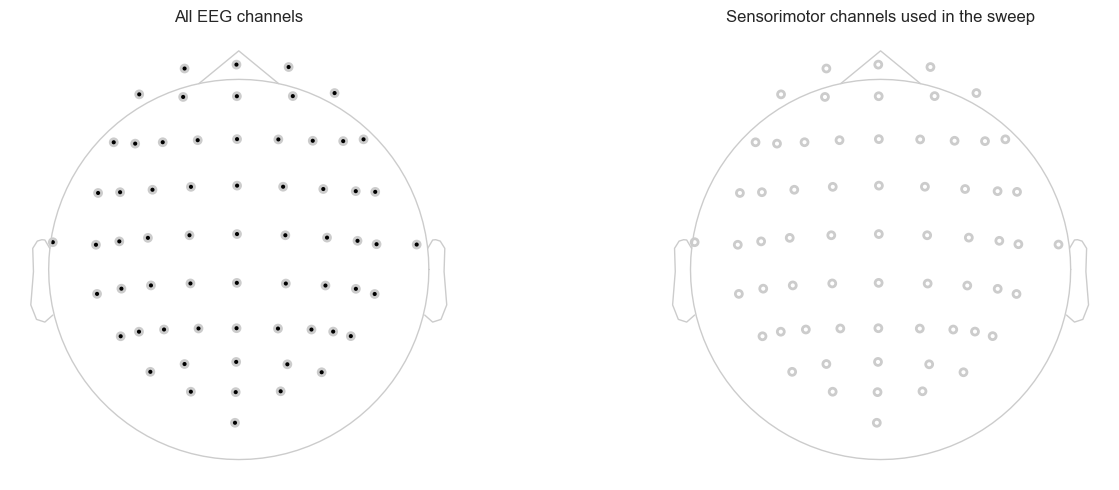

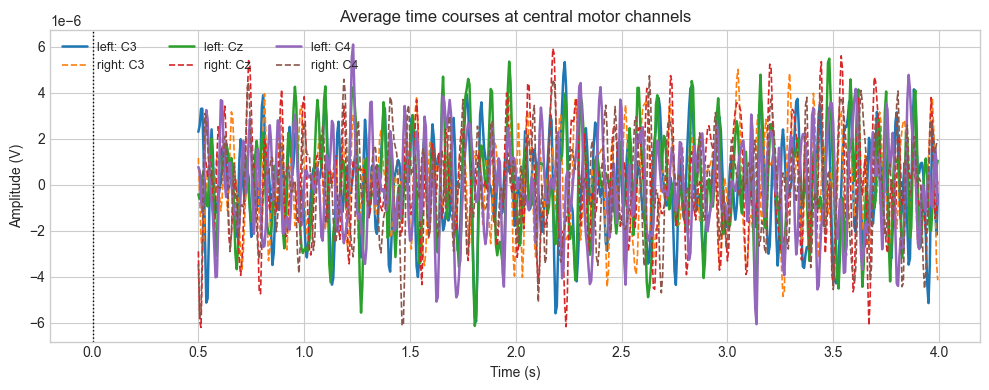

In [4]:
sensorimotor_union = []
for subset in SENSORIMOTOR_CHANNEL_SETS.values():
    sensorimotor_union.extend(subset)
sensorimotor_union = [
    ch for ch in dict.fromkeys(sensorimotor_union) if ch in dataset["channel_names"]
]
sensorimotor_indices = [
    dataset["example_epochs"].ch_names.index(ch) for ch in sensorimotor_union
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mne.viz.plot_sensors(
    dataset["example_epochs"].info,
    axes=axes[0],
    show=False,
    kind="topomap",
)
axes[0].set_title("All EEG channels")

mne.viz.plot_sensors(
    dataset["example_epochs"].info,
    axes=axes[1],
    show=False,
    kind="topomap",
    ch_groups=[sensorimotor_indices],
)
axes[1].set_title("Sensorimotor channels used in the sweep")

plt.tight_layout()
plt.show()

motor_channels = [
    ch for ch in ["C3", "Cz", "C4"] if ch in dataset["example_epochs"].ch_names
]
if motor_channels:
    fig, ax = plt.subplots(figsize=(10, 4))
    left_evoked = dataset["example_epochs"]["left_hand"].average().pick(motor_channels)
    right_evoked = (
        dataset["example_epochs"]["right_hand"].average().pick(motor_channels)
    )
    times = left_evoked.times
    for ch_name in motor_channels:
        ch_idx = left_evoked.ch_names.index(ch_name)
        ax.plot(
            times, left_evoked.data[ch_idx], label=f"left: {ch_name}", linewidth=1.8
        )
        ax.plot(
            times,
            right_evoked.data[ch_idx],
            label=f"right: {ch_name}",
            linewidth=1.2,
            linestyle="--",
        )
    ax.axvline(0.0, color="black", linestyle=":", linewidth=1)
    ax.set_title("Average time courses at central motor channels")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (V)")
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


In [5]:
def make_subject_split(
    groups: np.ndarray,
    test_size: float = TEST_SIZE,
    val_size: float = VAL_SIZE,
    seed: int = SEED,
) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))

    inner_groups = groups[train_val_idx]
    inner_index = np.arange(len(train_val_idx))
    inner = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(inner.split(inner_index, groups=inner_groups))

    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def zscore_from_train(
    X_train: np.ndarray, *others: np.ndarray
) -> tuple[np.ndarray, ...]:
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)
    normalized = [(X_train - mean) / std]
    for X in others:
        normalized.append((X - mean) / std)
    return tuple(normalized)


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def evaluate_torch_model(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * len(batch_y)
        total_correct += (logits.argmax(dim=1) == batch_y).sum().item()
        total_count += len(batch_y)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def build_torch_model(
    model_name: str, n_chans: int, n_times: int, sfreq: float, chs_info: list[dict]
) -> nn.Module:
    common = dict(
        n_chans=n_chans,
        n_outputs=2,
        n_times=n_times,
        sfreq=sfreq,
        chs_info=chs_info,
    )
    if model_name == "EEGNet":
        return EEGNet(**common)
    if model_name == "ShallowConvNet":
        return ShallowFBCSPNet(**common)
    if model_name == "DeepConvNet":
        return Deep4Net(**common)
    if model_name == "AttentionBaseNet":
        return AttentionBaseNet(**common)
    if model_name == "CTNet":
        return CTNet(**common)
    if model_name == "FBLightConvNet":
        return FBLightConvNet(**common)
    if model_name == "FBCNet":
        return FBCNet(**common)
    if model_name == "ATCNet":
        return ATCNet(**common)
    raise KeyError(f"Unknown model name: {model_name}")


def run_csp_lda(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
) -> dict:
    start = time.perf_counter()
    clf = Pipeline(
        [
            (
                "csp",
                CSP(
                    n_components=max(2, min(6, X_train.shape[1])),
                    reg="oas",
                    log=True,
                    norm_trace=False,
                ),
            ),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    clf.fit(X_train, y_train)
    train_time = time.perf_counter() - start
    return {
        "val_accuracy": clf.score(X_val, y_val),
        "test_accuracy": clf.score(X_test, y_test),
        "train_time_s": train_time,
        "best_epoch": 1,
        "status": "ok",
    }


def run_torch_benchmark(
    model_name: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    sfreq: float,
    chs_info: list[dict],
) -> dict:
    set_seed(SEED)
    X_train_z, X_val_z, X_test_z = zscore_from_train(X_train, X_val, X_test)
    train_loader = make_loader(X_train_z, y_train, shuffle=True)
    val_loader = make_loader(X_val_z, y_val, shuffle=False)
    test_loader = make_loader(X_test_z, y_test, shuffle=False)

    model = build_torch_model(
        model_name=model_name,
        n_chans=X_train.shape[1],
        n_times=X_train.shape[2],
        sfreq=sfreq,
        chs_info=chs_info,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    best_state = None
    best_val_accuracy = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        _, val_accuracy = evaluate_torch_model(model, val_loader, criterion)
        if val_accuracy > best_val_accuracy + 1e-4:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    train_time = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)

    _, final_val_accuracy = evaluate_torch_model(model, val_loader, criterion)
    _, test_accuracy = evaluate_torch_model(model, test_loader, criterion)

    return {
        "val_accuracy": final_val_accuracy,
        "test_accuracy": test_accuracy,
        "train_time_s": train_time,
        "best_epoch": best_epoch,
        "status": "ok",
    }


def benchmark_models(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    channel_names: list[str],
    chs_info: list[dict],
    sfreq: float,
    model_names: list[str] | None = None,
    split: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    if split is None:
        split = make_subject_split(groups)

    model_names = model_names or MODEL_NAMES
    X_train, y_train = X[split["train"]], y[split["train"]]
    X_val, y_val = X[split["val"]], y[split["val"]]
    X_test, y_test = X[split["test"]], y[split["test"]]

    results = []
    for model_name in model_names:
        print(f"Running {model_name} on {len(channel_names)} channels...")
        try:
            if model_name == "CSP + LDA":
                result = run_csp_lda(X_train, y_train, X_val, y_val, X_test, y_test)
            else:
                result = run_torch_benchmark(
                    model_name=model_name,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    X_test=X_test,
                    y_test=y_test,
                    sfreq=sfreq,
                    chs_info=chs_info,
                )
        except Exception as exc:
            result = {
                "val_accuracy": np.nan,
                "test_accuracy": np.nan,
                "train_time_s": np.nan,
                "best_epoch": np.nan,
                "status": f"failed: {type(exc).__name__}: {exc}",
            }

        result.update(
            {
                "model": model_name,
                "n_channels": len(channel_names),
            }
        )
        results.append(result)

    results_df = pd.DataFrame(results)
    results_df = results_df[
        [
            "model",
            "n_channels",
            "val_accuracy",
            "test_accuracy",
            "train_time_s",
            "best_epoch",
            "status",
        ]
    ]
    return results_df, split


def resolve_channel_subsets(
    channel_names: list[str], desired_subsets: dict[str, list[str]]
) -> dict[str, list[str]]:
    available = []
    for subset_name, subset_channels in desired_subsets.items():
        resolved = [ch for ch in subset_channels if ch in channel_names]
        if len(resolved) >= 3:
            available.append((subset_name, resolved))
    return dict(available)


def summarize_min_channels(
    results: pd.DataFrame, tolerance: float = MIN_CHANNEL_TOLERANCE
) -> pd.DataFrame:
    successful = results.query("status == 'ok'").copy()
    summaries = []
    for model_name, model_df in successful.groupby("model"):
        ranked = model_df.sort_values(
            ["n_channels", "test_accuracy"], ascending=[True, False]
        ).reset_index(drop=True)
        best_accuracy = ranked["test_accuracy"].max()
        eligible = ranked[ranked["test_accuracy"] >= best_accuracy - tolerance].iloc[0]
        summaries.append(
            {
                "model": model_name,
                "best_accuracy": best_accuracy,
                "min_channels_within_tolerance": int(eligible["n_channels"]),
                "recommended_subset": eligible["subset"],
                "recommended_accuracy": eligible["test_accuracy"],
            }
        )
    return pd.DataFrame(summaries).sort_values(
        ["min_channels_within_tolerance", "recommended_accuracy"],
        ascending=[True, False],
    )


In [6]:
all_channel_results, split_idx = benchmark_models(
    X=dataset["X"],
    y=dataset["y"],
    groups=dataset["groups"],
    channel_names=dataset["channel_names"],
    chs_info=dataset["chs_info"],
    sfreq=dataset["sfreq"],
    model_names=MODEL_NAMES,
)

display(
    all_channel_results.sort_values(
        ["status", "test_accuracy"], ascending=[True, False]
    )
)
successful_all = (
    all_channel_results.query("status == 'ok'")
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
successful_all


Running CSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running ShallowConvNet on 64 channels...
Running DeepConvNet on 64 channels...
Running AttentionBaseNet on 64 channels...
Running CTNet on 64 channels...


/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


Running FBLightConvNet on 64 channels...
Running FBCNet on 64 channels...
Running ATCNet on 64 channels...


,model,n_channels,val_accuracy,test_accuracy,train_time_s,best_epoch,status
6,FBLightConvNet,64,0.670792,0.586451,10.980825,6,ok
2,ShallowConvNet,64,0.663366,0.583418,7.592896,8,ok
7,FBCNet,64,0.652228,0.577351,10.224699,6,ok
1,EEGNet,64,0.667079,0.563195,16.804624,8,ok
4,AttentionBaseNet,64,0.663366,0.554095,26.346205,12,ok
5,CTNet,64,0.616337,0.550051,31.384654,11,ok
3,DeepConvNet,64,0.542079,0.536906,6.125646,5,ok
0,CSP + LDA,64,0.618812,0.535895,8.809006,1,ok
8,ATCNet,64,0.511139,0.493428,10.143832,1,ok


,model,n_channels,val_accuracy,test_accuracy,train_time_s,best_epoch,status
0,FBLightConvNet,64,0.670792,0.586451,10.980825,6,ok
1,ShallowConvNet,64,0.663366,0.583418,7.592896,8,ok
2,FBCNet,64,0.652228,0.577351,10.224699,6,ok
3,EEGNet,64,0.667079,0.563195,16.804624,8,ok
4,AttentionBaseNet,64,0.663366,0.554095,26.346205,12,ok
5,CTNet,64,0.616337,0.550051,31.384654,11,ok
6,DeepConvNet,64,0.542079,0.536906,6.125646,5,ok
7,CSP + LDA,64,0.618812,0.535895,8.809006,1,ok
8,ATCNet,64,0.511139,0.493428,10.143832,1,ok


In [7]:
all_channel_results["status"][0]

'ok'

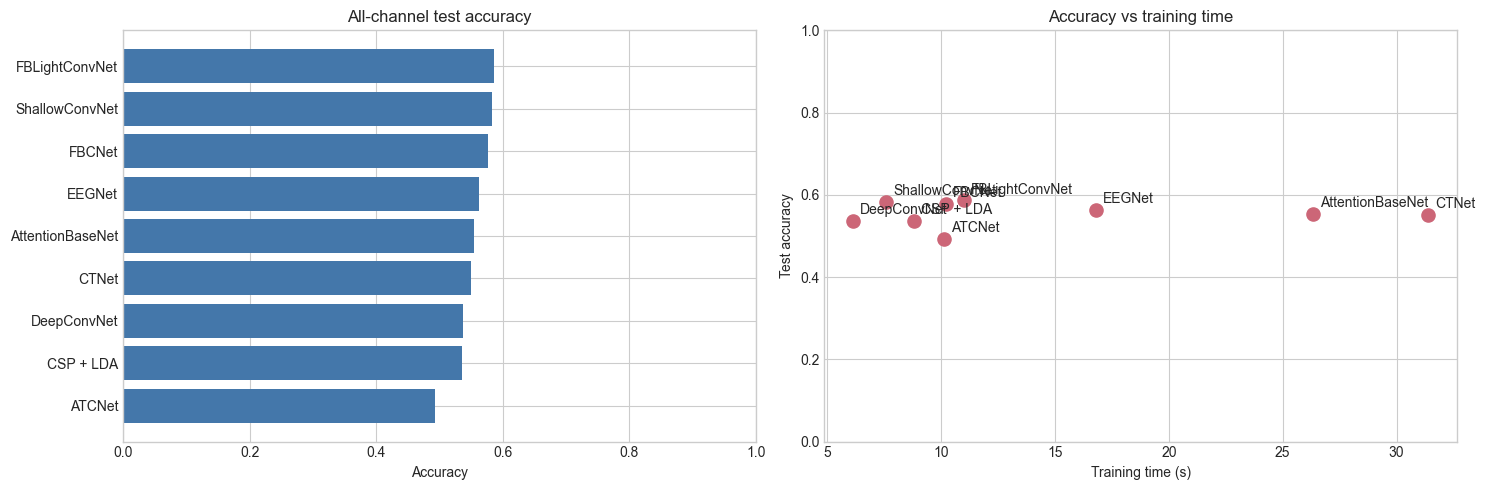

In [8]:
if successful_all.empty:
    print("No model finished successfully, so there is nothing to plot yet.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    order = successful_all.sort_values("test_accuracy", ascending=True)
    axes[0].barh(order["model"], order["test_accuracy"], color="#4477AA")
    axes[0].set_title("All-channel test accuracy")
    axes[0].set_xlabel("Accuracy")
    axes[0].set_xlim(0.0, 1.0)

    axes[1].scatter(
        successful_all["train_time_s"],
        successful_all["test_accuracy"],
        s=90,
        color="#CC6677",
    )
    for _, row in successful_all.iterrows():
        axes[1].annotate(
            row["model"],
            (row["train_time_s"], row["test_accuracy"]),
            xytext=(5, 5),
            textcoords="offset points",
        )
    axes[1].set_title("Accuracy vs training time")
    axes[1].set_xlabel("Training time (s)")
    axes[1].set_ylabel("Test accuracy")
    axes[1].set_ylim(0.0, 1.0)

    plt.tight_layout()
    plt.show()


In [9]:
available_channel_sets = resolve_channel_subsets(
    dataset["channel_names"], SENSORIMOTOR_CHANNEL_SETS
)
channel_set_table = pd.DataFrame(
    {
        "subset": list(available_channel_sets.keys()),
        "n_channels": [len(chs) for chs in available_channel_sets.values()],
        "channels": [", ".join(chs) for chs in available_channel_sets.values()],
    }
)
display(channel_set_table)

channel_study_models = CHANNEL_STUDY_MODELS
if channel_study_models is None:
    channel_study_models = successful_all["model"].tolist()

channel_result_frames = []
name_to_idx = {name: idx for idx, name in enumerate(dataset["channel_names"])}

for subset_name, subset_channels in available_channel_sets.items():
    picks = [name_to_idx[ch] for ch in subset_channels]
    subset_results, _ = benchmark_models(
        X=dataset["X"][:, picks, :],
        y=dataset["y"],
        groups=dataset["groups"],
        channel_names=subset_channels,
        chs_info=[deepcopy(dataset["chs_info"][idx]) for idx in picks],
        sfreq=dataset["sfreq"],
        model_names=channel_study_models,
        split=split_idx,
    )
    subset_results["subset"] = subset_name
    subset_results["subset_channels"] = ", ".join(subset_channels)
    channel_result_frames.append(subset_results)

subset_channel_results = (
    pd.concat(channel_result_frames, ignore_index=True)
    if channel_result_frames
    else pd.DataFrame(
        columns=list(all_channel_results.columns) + ["subset", "subset_channels"]
    )
)

all_channel_for_comparison = all_channel_results.copy()
all_channel_for_comparison["subset"] = "all_channels"
all_channel_for_comparison["subset_channels"] = ", ".join(dataset["channel_names"])

channel_sweep_results = pd.concat(
    [all_channel_for_comparison, subset_channel_results],
    ignore_index=True,
)

display(
    channel_sweep_results.sort_values(
        ["model", "n_channels", "test_accuracy"], ascending=[True, True, False]
    )
)


,subset,n_channels,channels
0,motor_strip_3,3,"C3, Cz, C4"
1,motor_strip_5,5,"FC3, C3, Cz, C4, FC4"
2,sensorimotor_9,9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
3,sensorimotor_17,17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."


Running FBLightConvNet on 3 channels...
Running ShallowConvNet on 3 channels...
Running FBCNet on 3 channels...
Running EEGNet on 3 channels...
Running AttentionBaseNet on 3 channels...
Running CTNet on 3 channels...
Running DeepConvNet on 3 channels...
Running CSP + LDA on 3 channels...
Running ATCNet on 3 channels...
Running FBLightConvNet on 5 channels...
Running ShallowConvNet on 5 channels...
Running FBCNet on 5 channels...
Running EEGNet on 5 channels...
Running AttentionBaseNet on 5 channels...
Running CTNet on 5 channels...
Running DeepConvNet on 5 channels...
Running CSP + LDA on 5 channels...
Running ATCNet on 5 channels...
Running FBLightConvNet on 9 channels...
Running ShallowConvNet on 9 channels...
Running FBCNet on 9 channels...
Running EEGNet on 9 channels...
Running AttentionBaseNet on 9 channels...
Running CTNet on 9 channels...
Running DeepConvNet on 9 channels...
Running CSP + LDA on 9 channels...
Running ATCNet on 9 channels...
Running FBLightConvNet on 17 channels

,model,n_channels,val_accuracy,test_accuracy,train_time_s,best_epoch,status,subset,subset_channels
17,ATCNet,3,0.625000,0.563195,18.483010,10,ok,motor_strip_3,"C3, Cz, C4"
26,ATCNet,5,0.571782,0.544995,8.186044,3,ok,motor_strip_5,"FC3, C3, Cz, C4, FC4"
35,ATCNet,9,0.652228,0.560162,15.848254,12,ok,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
44,ATCNet,17,0.540842,0.527806,6.578717,2,ok,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
8,ATCNet,64,0.511139,0.493428,10.143832,1,ok,all_channels,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
13,AttentionBaseNet,3,0.633663,0.565217,6.830277,12,ok,motor_strip_3,"C3, Cz, C4"
22,AttentionBaseNet,5,0.626238,0.530839,6.074927,7,ok,motor_strip_5,"FC3, C3, Cz, C4, FC4"
31,AttentionBaseNet,9,0.680693,0.565217,3.890908,10,ok,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
40,AttentionBaseNet,17,0.668317,0.579373,5.302451,10,ok,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
4,AttentionBaseNet,64,0.663366,0.554095,26.346205,12,ok,all_channels,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."


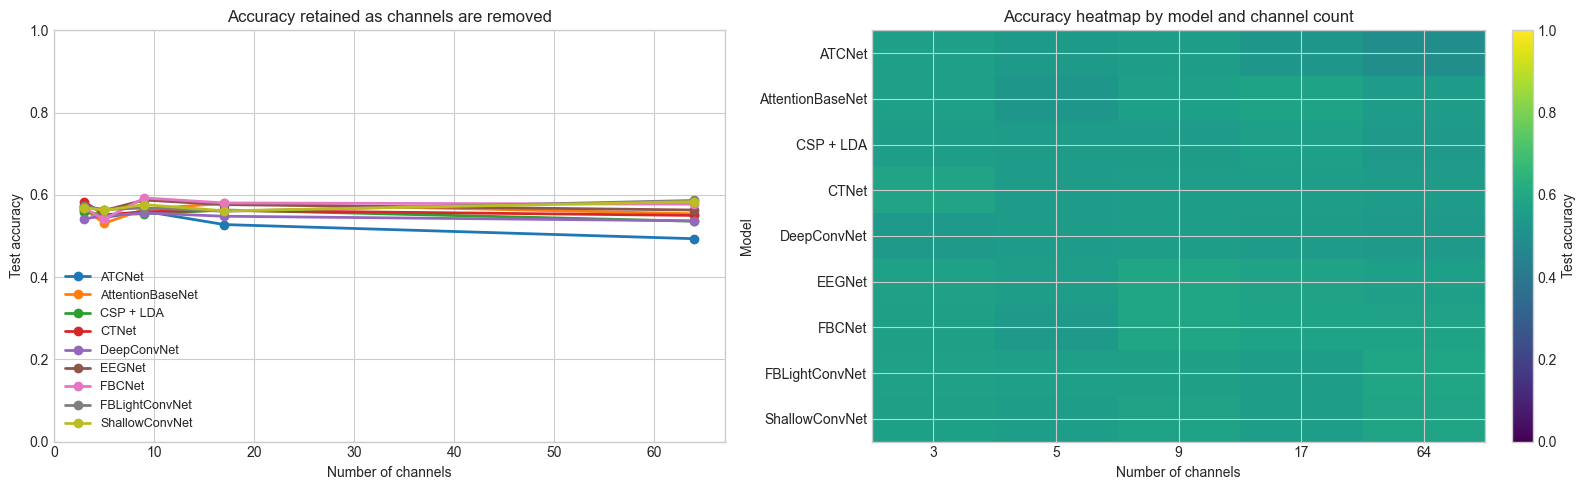

,model,best_accuracy,min_channels_within_tolerance,recommended_subset,recommended_accuracy
3,CTNet,0.583418,3,motor_strip_3,0.583418
5,EEGNet,0.587462,3,motor_strip_3,0.573306
7,FBLightConvNet,0.586451,3,motor_strip_3,0.572295
8,ShallowConvNet,0.583418,3,motor_strip_3,0.569262
1,AttentionBaseNet,0.579373,3,motor_strip_3,0.565217
0,ATCNet,0.563195,3,motor_strip_3,0.563195
2,CSP + LDA,0.563195,3,motor_strip_3,0.558140
4,DeepConvNet,0.556117,3,motor_strip_3,0.541962
6,FBCNet,0.592518,9,sensorimotor_9,0.592518


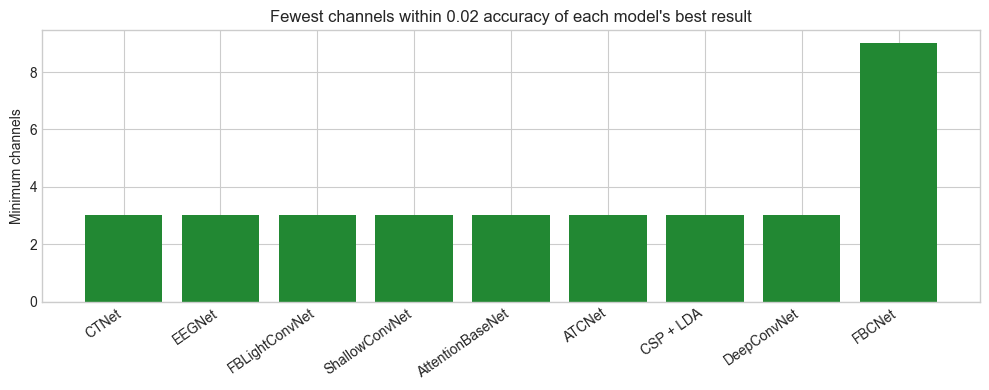

In [10]:
successful_sweep = channel_sweep_results.query("status == 'ok'").copy()

if successful_sweep.empty:
    print("No channel-sweep runs finished successfully.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for model_name, model_df in successful_sweep.groupby("model"):
        model_df = model_df.sort_values("n_channels")
        axes[0].plot(
            model_df["n_channels"],
            model_df["test_accuracy"],
            marker="o",
            linewidth=2,
            label=model_name,
        )
    axes[0].set_title("Accuracy retained as channels are removed")
    axes[0].set_xlabel("Number of channels")
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].legend(loc="best", fontsize=9)

    pivot = (
        successful_sweep.pivot_table(
            index="model", columns="n_channels", values="test_accuracy", aggfunc="max"
        )
        .sort_index()
        .sort_index(axis=1)
    )
    image = axes[1].imshow(
        pivot.values, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0
    )
    axes[1].set_title("Accuracy heatmap by model and channel count")
    axes[1].set_xlabel("Number of channels")
    axes[1].set_ylabel("Model")
    axes[1].set_xticks(np.arange(len(pivot.columns)))
    axes[1].set_xticklabels(pivot.columns.astype(int))
    axes[1].set_yticks(np.arange(len(pivot.index)))
    axes[1].set_yticklabels(pivot.index)
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04, label="Test accuracy")

    plt.tight_layout()
    plt.show()

    min_channel_summary = summarize_min_channels(
        successful_sweep, tolerance=MIN_CHANNEL_TOLERANCE
    )
    display(min_channel_summary)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(
        min_channel_summary["model"],
        min_channel_summary["min_channels_within_tolerance"],
        color="#228833",
    )
    ax.set_title(
        f"Fewest channels within {MIN_CHANNEL_TOLERANCE:.02f} accuracy of each model's best result"
    )
    ax.set_ylabel("Minimum channels")
    plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
